Track 4 - k-mer Based
- k-mer tokentization
- k-mer TF-IDF matrix (Try k values 3, 5, 7)
- Dimensionality reduction (if applicable)
- Clustering

Preprocessing:
- Parsing FASTA coordinates and sequences with Biopython
- FIMO.gff was cleaned as follows: Ran Tomtom on .meme file against itself to assign to a grouping extremely similar motifs, mapped groupings to FIMO.gff and collapsed overlapping motifs from same grouping

In [20]:
from Bio import SeqIO
import pandas as pd

sequences = []
coords = []

#Fasta file for ACRs
for record in SeqIO.parse("/Users/avery/Downloads/dACR.fa", "fasta"):
    sequences.append(str(record.seq))
    coords.append(record.id)

gff = pd.read_csv(
    "/Users/avery/fimo_collapsed_with_metadata.csv"
)

def extract_alias(attr):
    for field in attr.split(";"):
        if field.startswith("Alias="):
            return field.split("=")[1]
    return None

gff["Alias"] = gff["attributes"].apply(extract_alias)
gff["sequence_id"] = gff["seqid"].astype(str).str.strip()

print(gff.shape)

(57852, 18)


In [21]:
from Bio.Seq import Seq
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

##########################################################
# CANONICAL K-MER FUNCTION
##########################################################

def canonical_kmer(kmer):
    rc = str(Seq(kmer).reverse_complement())
    return min(kmer, rc)

##########################################################
# CREATE TF-IDF MATRICES
##########################################################

kmer_matrices = {}

for k in [3, 5, 7]:

    def kmer_analyzer(sequence, k=k):
        sequence = sequence.upper().replace("N", "")
        kmers = []

        for i in range(len(sequence) - k + 1):
            kmer = sequence[i:i+k]
            kmers.append(canonical_kmer(kmer))

        return kmers

    vectorizer = TfidfVectorizer(
        analyzer=kmer_analyzer,
        min_df=2
    )

    X_tfidf = vectorizer.fit_transform(sequences)

    tfidf_df = pd.DataFrame(
        X_tfidf.toarray(),
        index=coords,
        columns=vectorizer.get_feature_names_out()
    )

    kmer_matrices[f"kmer_{k}"] = tfidf_df

    print(f"k = {k}")
    print(tfidf_df.shape)

k = 3
(31295, 32)
k = 5
(31295, 512)
k = 7
(31295, 8192)


In [22]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

N_CLUSTERS = 5

##########################################################
# KMEANS STABILITY
##########################################################

def kmeans_stability(X, n_clusters=5, runs=10):

    label_sets = []

    for seed in range(runs):

        labels = KMeans(
            n_clusters=n_clusters,
            random_state=seed,
            n_init=10
        ).fit_predict(X)

        label_sets.append(labels)

    ari_scores = []

    for i in range(runs):
        for j in range(i + 1, runs):

            ari_scores.append(
                adjusted_rand_score(
                    label_sets[i],
                    label_sets[j]
                )
            )

    return np.mean(ari_scores)

##########################################################
# EVALUATION
##########################################################

def evaluate(X, labels, representation, method):

    labels = np.asarray(labels)

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    silhouette = silhouette_score(X, labels)

    calinski = calinski_harabasz_score(
        X,
        labels
    )

    davies = davies_bouldin_score(
        X,
        labels
    )

    if method == "KMeans":

        stability = kmeans_stability(
            X,
            N_CLUSTERS
        )

    else:

        stability = np.nan

    return {

        "Representation": representation,

        "Method": method,

        "Clusters": len(cluster_sizes),

        "Largest Cluster": cluster_sizes.max(),

        "Smallest Cluster": cluster_sizes.min(),

        "Silhouette": silhouette,

        "Calinski-Harabasz": calinski,

        "Davies-Bouldin": davies,

        "ARI Stability": stability
    }

##########################################################
# RUN ALL MATRICES
##########################################################

results = []

# Store labels for biological evaluation and visualization
cluster_results = {}

for name, X in kmer_matrices.items():

    print(f"Running {name}")

    ######################################################
    # KMEANS
    ######################################################

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        n_init=10
    )

    kmeans_labels = kmeans.fit_predict(X)
    cluster_results[(name, "KMeans")] = pd.Series(
    kmeans_labels,
    index=X.index
    )

    results.append(
        evaluate(
            X,
            kmeans_labels,
            name,
            "KMeans"
        )
    )

    ######################################################
    # HIERARCHICAL
    ######################################################

    hierarchical = AgglomerativeClustering(
        n_clusters=N_CLUSTERS,
        linkage="ward"
    )

    hierarchical_labels = hierarchical.fit_predict(X)

    cluster_results[(name, "Hierarchical")] = pd.Series(
    hierarchical_labels,
    index=X.index
    )
    
    results.append(
        evaluate(
            X,
            hierarchical_labels,
            name,
            "Hierarchical"
        )
    )

##########################################################
# SAVE
##########################################################

results_df = pd.DataFrame(results)

results_df.to_csv(
    "track4_cluster_evaluation.csv",
    index=False
)

print(results_df)

Running kmer_3
Running kmer_5
Running kmer_7
  Representation        Method  Clusters  Largest Cluster  Smallest Cluster  \
0         kmer_3        KMeans         5             7574              2714   
1         kmer_3  Hierarchical         5             9116              3618   
2         kmer_5        KMeans         5             9860               491   
3         kmer_5  Hierarchical         5            12161               419   
4         kmer_7        KMeans         5            11135               476   
5         kmer_7  Hierarchical         5            12868               149   

   Silhouette  Calinski-Harabasz  Davies-Bouldin  ARI Stability  
0    0.075979        3669.011625        2.480752       0.954123  
1    0.028336        2862.052028        2.838060            NaN  
2    0.009972         697.868060        4.848009       0.985410  
3   -0.002241         514.413306        5.551941            NaN  
4   -0.000738         152.449159        9.695655       0.807284  
5   -

Plotting kmer_3 - KMeans


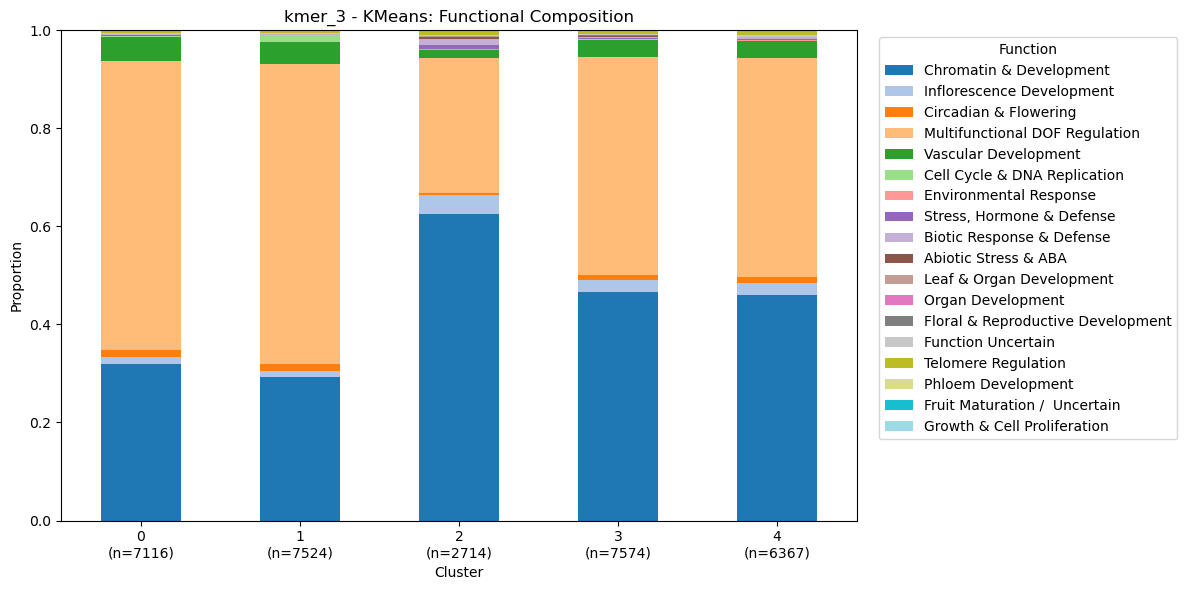

Plotting kmer_3 - Hierarchical


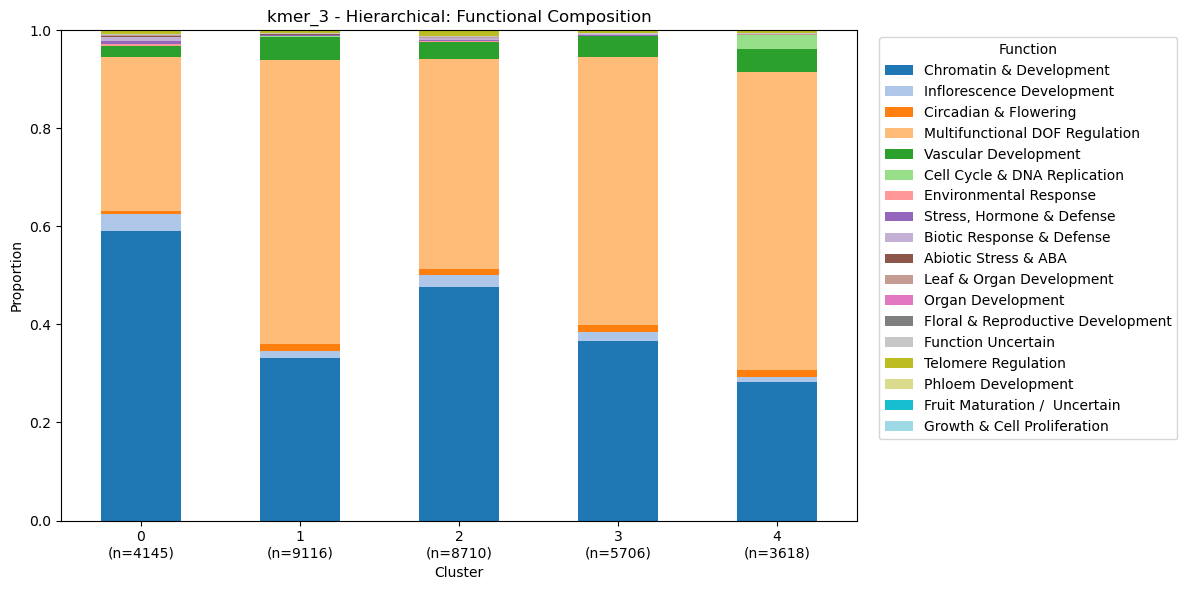

Plotting kmer_5 - KMeans


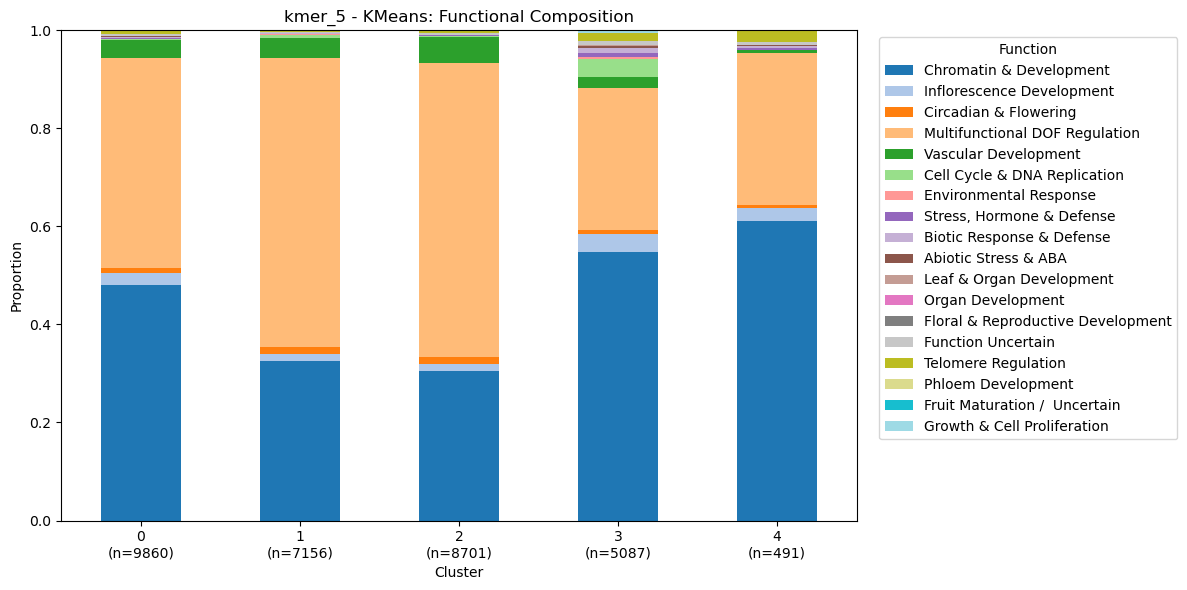

Plotting kmer_5 - Hierarchical


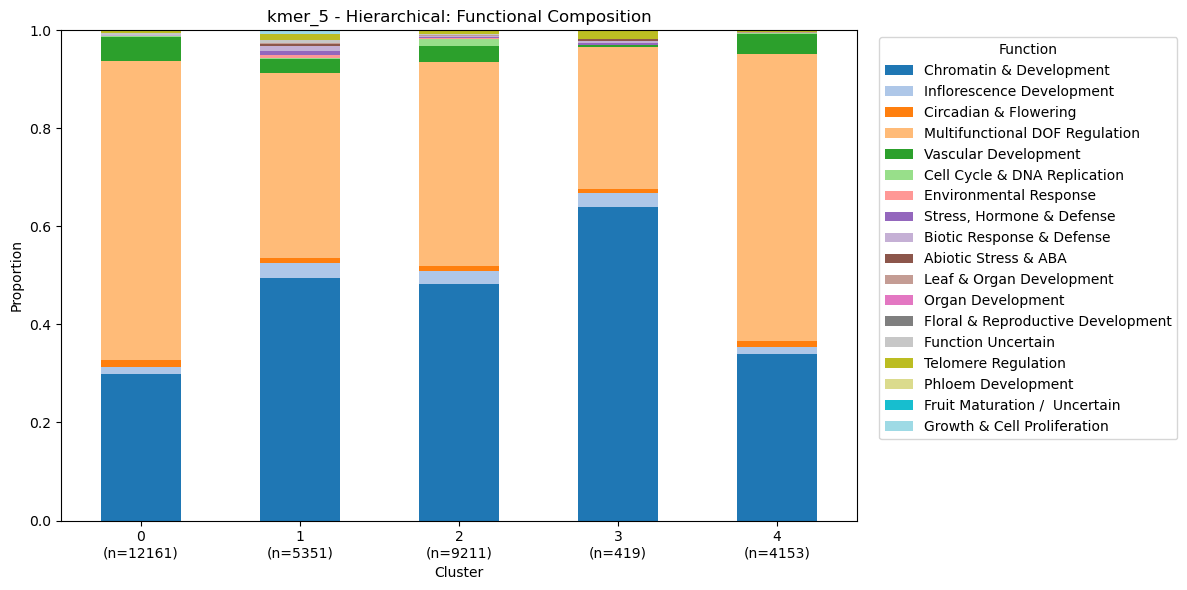

Plotting kmer_7 - KMeans


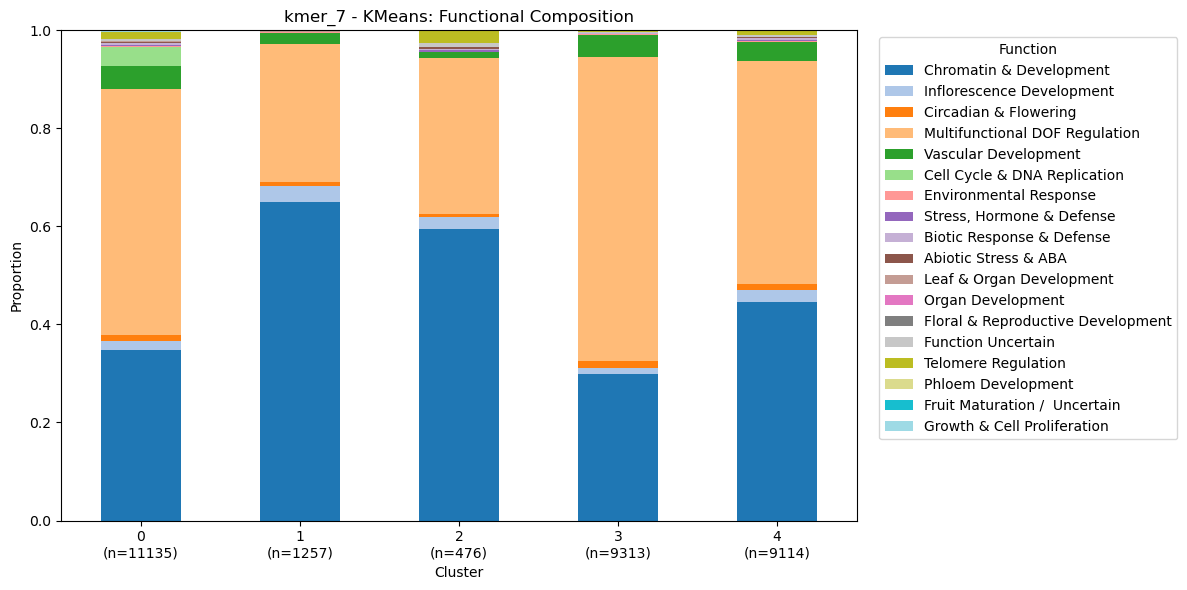

Plotting kmer_7 - Hierarchical


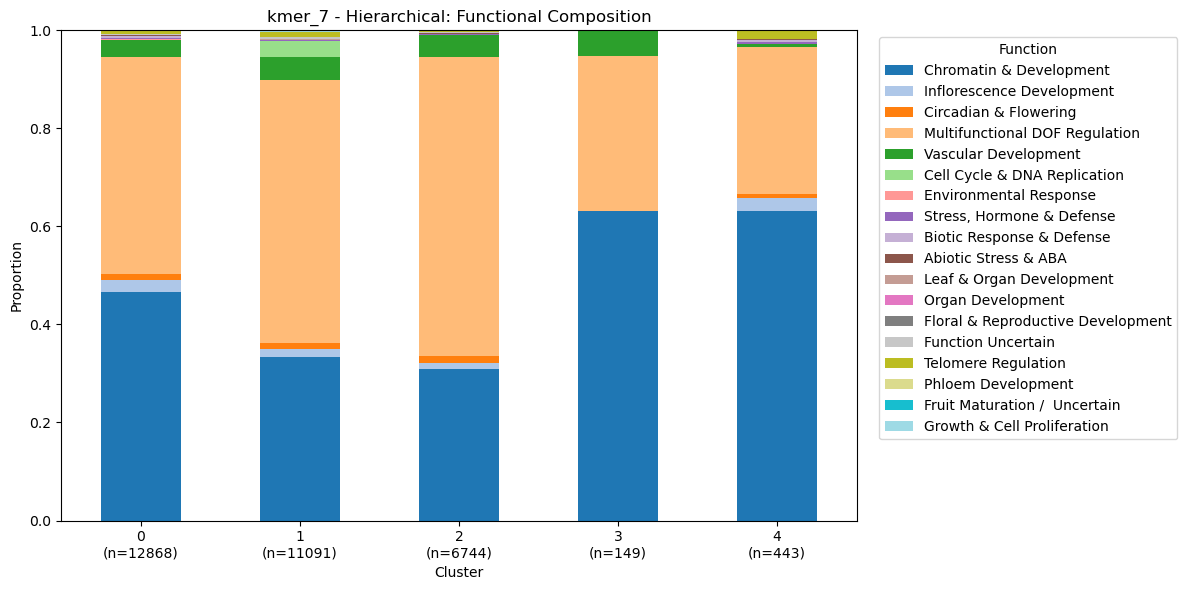

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

functional_groups = {
    'Chromatin & Development': ['BPC1', 'BPC5', 'BPC6'],
    'Inflorescence Development': ['RAMOSA1'],
    'Circadian & Flowering': ['CDF5'],
    'Multifunctional DOF Regulation': ['DOF3.6', 'DOF5.1', 'DOF3.4', 'DOF1.5'],
    'Vascular Development': ['DOF5.8'],
    'Cell Cycle & DNA Replication': ['E2FD', 'E2FE'],
    'Environmental Response': ['DREB2D', 'ERF095'],
    'Stress, Hormone & Defense': ['ERF014', 'ERF057', 'ERF091', 'ERF104', 'ERF2', 'ERF5'],
    'Biotic Response & Defense': ['ERF9'],
    'Abiotic Stress & ABA': ['RAP2-6'],
    'Leaf & Organ Development': ['AS2'],
    'Organ Development': ['LOB'],
    'Floral & Reproductive Development': ['AGL6'],
    'Function Uncertain': ['AT4G12670'],
    'Telomere Regulation': ['TRP1', 'TRP2'],
    'Phloem Development': ['NAC020'],
    'Fruit Maturation /  Uncertain': ['NAC058'],
    'Growth & Cell Proliferation': ['TCP14']
}


alias_to_function = {
    motif: func
    for func, motifs in functional_groups.items()
    for motif in motifs
}

all_functions = list(functional_groups.keys())


if "Function" not in gff.columns:
    gff["Alias"] = gff["attributes"].str.extract(r"Alias=([^;]+)")
    gff["Function"] = gff["Alias"].map(alias_to_function)

if "sequence_id" not in gff.columns:
    gff["sequence_id"] = gff["seqid"].astype(str).str.strip()

##########################################################
# FUNCTIONAL COMPOSITION
##########################################################

def get_cluster_composition(cluster_labels):

    temp = gff.copy()

    temp["cluster"] = temp["sequence_id"].map(cluster_labels)

    temp = temp.dropna(subset=["Function", "cluster"])

    counts = (
        pd.crosstab(
            temp["cluster"],
            temp["Function"]
        )
        .reindex(columns=all_functions, fill_value=0)
    )

    proportions = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    cluster_sizes = (
        cluster_labels
        .value_counts()
        .sort_index()
    )

    return proportions, cluster_sizes

##########################################################
# PLOTTING
##########################################################

def plot_stacked(df, cluster_sizes, title):

    ax = df.plot(
        kind="bar",
        stacked=True,
        figsize=(12,6),
        colormap="tab20"
    )

    labels = [
        f"{cluster}\n(n={cluster_sizes.loc[cluster]})"
        for cluster in df.index
    ]

    ax.set_xticklabels(labels, rotation=0)

    plt.ylabel("Proportion")
    plt.xlabel("Cluster")
    plt.title(title)
    plt.ylim(0,1)

    plt.legend(
        title="Function",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

##########################################################
# PLOTS
##########################################################

for (representation, method), labels in cluster_results.items():

    print(f"Plotting {representation} - {method}")

    composition, cluster_sizes = get_cluster_composition(labels)

    plot_stacked(
        composition,
        cluster_sizes,
        f"{representation} - {method}: Functional Composition"
    )

In [25]:
from scipy.stats import chi2_contingency
from scipy.stats import entropy

##########################################################
# BIOLOGICAL EVALUATION
##########################################################

def biological_summary(cluster_labels, representation, method):

    temp = gff.copy()

    temp["cluster"] = temp["sequence_id"].map(cluster_labels)
    temp = temp.dropna(subset=["Function", "cluster"])

    ######################################################
    # Cluster sizes (number of ACRs)
    ######################################################

    cluster_sizes = (
        cluster_labels
        .value_counts()
        .sort_index()
    )

    ######################################################
    # Contingency table
    ######################################################

    counts = (
        pd.crosstab(
            temp["cluster"],
            temp["Function"]
        )
        .reindex(columns=all_functions, fill_value=0)
    )

    ######################################################
    # Chi-square
    ######################################################

    chi_counts = counts.loc[:, counts.sum(axis=0) > 0]

    chi2, p, dof, expected = chi2_contingency(chi_counts)

    ######################################################
    # Proportions
    ######################################################

    proportions = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    ######################################################
    # Summary table
    ######################################################

    rows = []

    for cluster in proportions.index:

        top3 = (
            proportions.loc[cluster]
            .sort_values(ascending=False)
            .head(3)
        )

        shannon = entropy(
            proportions.loc[cluster],
            base=2
        )

        rows.append({
            "Representation": representation,
            
            "Method": method,

            "Chi-square p": "<0.001" if p < 0.001 else f"{p:.3f}",

            "Cluster": cluster,

            "Cluster Size (ACRs)": int(cluster_sizes.loc[cluster]),

            "Shannon Diversity Index": round(shannon, 3),

            "Top Function 1": top3.index[0],
            "Top 1 (%)": round(top3.iloc[0] * 100, 2),

            "Top Function 2": top3.index[1],
            "Top 2 (%)": round(top3.iloc[1] * 100, 2),

            "Top Function 3": top3.index[2],
            "Top 3 (%)": round(top3.iloc[2] * 100, 2)

        })

    return pd.DataFrame(rows)

bio_results = []

for (representation, method), labels in cluster_results.items():

    bio_results.append(
        biological_summary(
            labels,
            representation,
            method
        )
    )

bio_results = pd.concat(
    bio_results,
    ignore_index=True
)

bio_results.to_csv(
    "track4_biological_summary.csv",
    index=False
)

print(bio_results)

   Representation        Method Chi-square p  Cluster  Cluster Size (ACRs)  \
0          kmer_3        KMeans       <0.001        0                 7116   
1          kmer_3        KMeans       <0.001        1                 7524   
2          kmer_3        KMeans       <0.001        2                 2714   
3          kmer_3        KMeans       <0.001        3                 7574   
4          kmer_3        KMeans       <0.001        4                 6367   
5          kmer_3  Hierarchical       <0.001        0                 4145   
6          kmer_3  Hierarchical       <0.001        1                 9116   
7          kmer_3  Hierarchical       <0.001        2                 8710   
8          kmer_3  Hierarchical       <0.001        3                 5706   
9          kmer_3  Hierarchical       <0.001        4                 3618   
10         kmer_5        KMeans       <0.001        0                 9860   
11         kmer_5        KMeans       <0.001        1           